In [1]:
import sys
sys.path.append("../src")
import decam_info
from decam_dataset import DECamImageDataset

In [2]:
sys.path.append("../../img-spec-ml/src/")
from plot_utils import plot_zscale_image

In [3]:
import matplotlib.pyplot as plt
from pathlib import Path

In [4]:
import h5py
import numpy as np

In [5]:
root_dir = Path("/pscratch/sd/b/brookluo/decam-exposure")
exp_name = "dino_v2"
exp_dir = root_dir / exp_name
eval_dir = exp_dir / "eval"
# data_dir = root_dir / "data"
ckpt_dir = exp_dir / "checkpoint"
# test_dir = data_dir / "test"

embeds_dir = eval_dir / "embeds_out"

model = "base"
model_dir = embeds_dir / model
train_dir = model_dir / "train"
test_dir = model_dir / "test"
    
plot_dir = eval_dir / "plots"

In [6]:
def read_embeds(outdir, num=4):
    data = []
    idx = []
    label = []
    for i in range(num):
        with h5py.File(outdir / f"{i}_worker_embeds.h5", 'r') as h5f:
            dset = h5f["images"]
            for it in dset:
                data.append(np.array(dset[it]))
                names = it.split("_")
                idx.append(names[1])
                label.append(names[-1])
    return data, idx, label

In [7]:
train_data, train_idx, train_label = read_embeds(train_dir)
train_embeds = np.vstack([np.mean(it, axis=0) for it in train_data])

In [20]:
idx = np.array(train_idx, dtype=int)
label = np.array(train_label, dtype=int)

In [8]:
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
import joblib

In [9]:
single_arr = StandardScaler().fit_transform(train_embeds)

In [25]:
pca_components = 100
n_clusters = 20
percent = prop * 100

In [26]:
# %%time
# pca = PCA(n_components='mle', svd_solver='full')
#pca = PCA(n_components=0.99999, svd_solver='full')
# question: using one PCA for all or each image has its separate PCA?
pca = PCA(n_components=pca_components, svd_solver='auto')
# pca.fit(arr_img)

In [27]:
trans_all = pca.fit_transform(single_arr)

In [39]:
from sklearn.cluster import HDBSCAN, DBSCAN

In [60]:
hdb = HDBSCAN(min_cluster_size=5, max_cluster_size=500, n_jobs=10)

In [61]:
hdb.fit(trans_all)

HDBSCAN(max_cluster_size=500, n_jobs=10)

In [62]:
# tsne_all = np.load(train_dir / f"tsne_samp_{int(percent)}per_pca{pca_components}.npy")

Text(0, 0.5, 'tSNE axis-2')

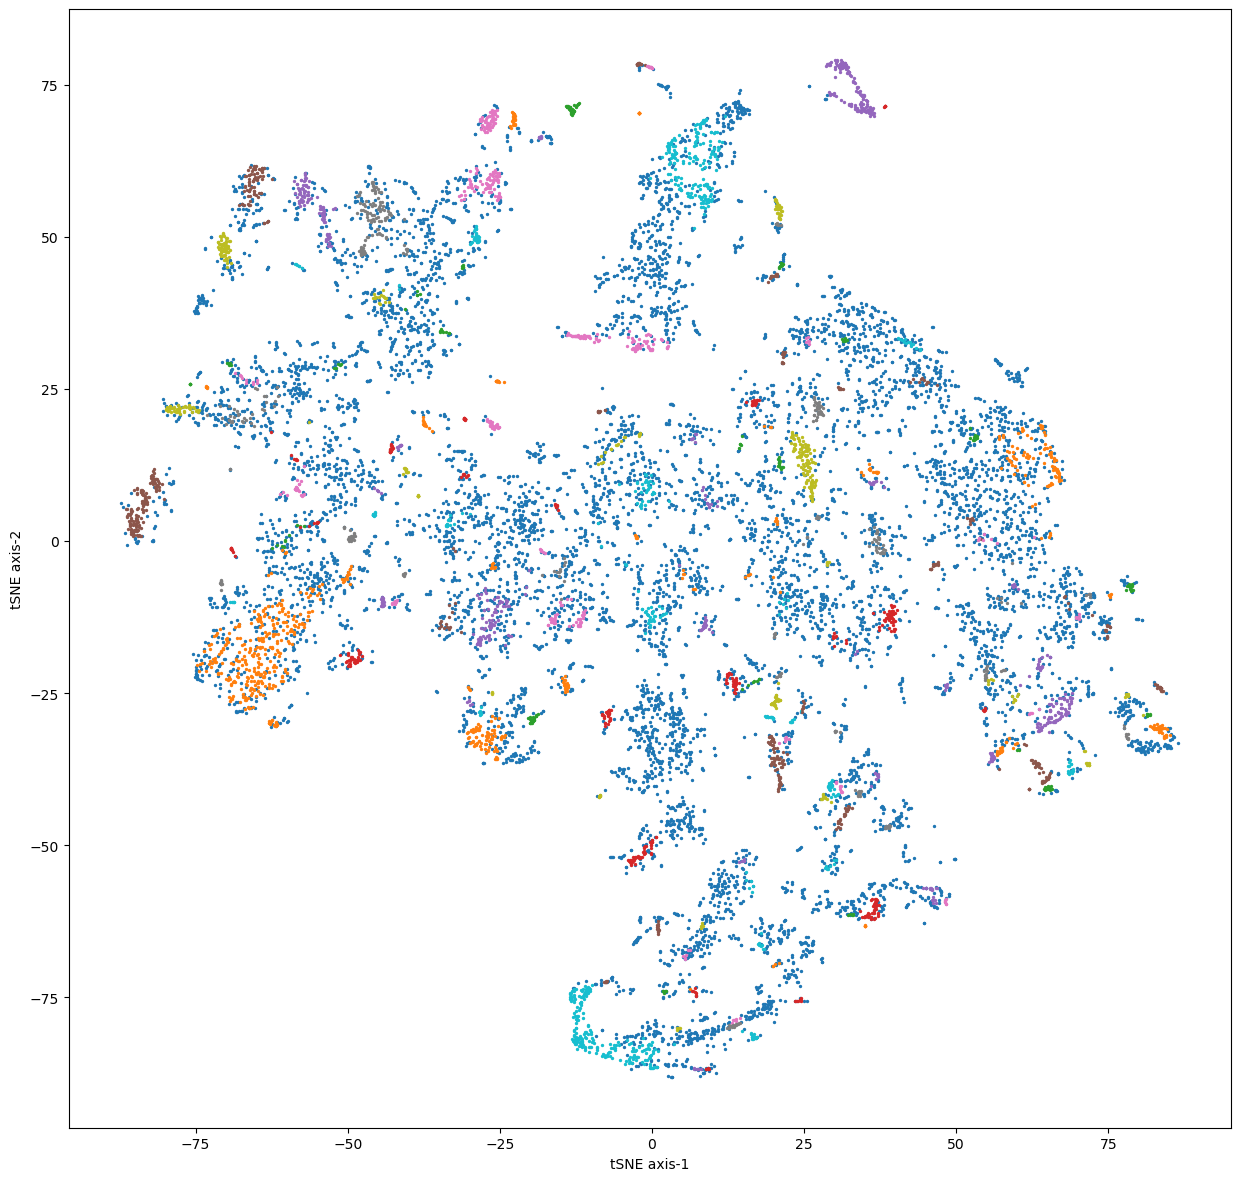

In [63]:
plt.figure(figsize=(15, 15))
for i in np.unique(hdb.labels_):
    plt.scatter(tsne_all[hdb.labels_==i, 0], tsne_all[hdb.labels_==i, 1], s=2, label=i)
plt.gca().set_aspect("equal")
plt.xlabel("tSNE axis-1")
plt.ylabel("tSNE axis-2")
# plt.legend(loc="upper right")
# lgnd = plt.legend(loc="upper right", scatterpoints=1, fontsize=10)
# for hdl in lgnd.legendHandles:
#     hdl._sizes = [30]
# plt.savefig(plot_dir / f"train_pca{pca_components}_cluster{n_clusters}_percent{percent}_clustering.png", bbox_inches='tight')